In [3]:
import boto3
import pandas as pd

# Simple S3 setup - no SageMaker SDK needed
s3_client = boto3.client('s3')
sts_client = boto3.client('sts')

# Get account ID
account_id = sts_client.get_caller_identity()['Account']
bucket_name = f'hiring-bias-{account_id}'

print(f"Account ID: {account_id}")
print(f"Creating bucket: {bucket_name}")

# Create S3 bucket
try:
    s3_client.create_bucket(Bucket=bucket_name)
    print(f"✓ Bucket created successfully!")
except Exception as e:
    print(f"Bucket may already exist: {e}")

# Set S3 path
s3_path = f's3://{bucket_name}/data/raw/'
print(f"✓ Data path: {s3_path}")

Account ID: 505929363203
Creating bucket: hiring-bias-505929363203
✓ Bucket created successfully!
✓ Data path: s3://hiring-bias-505929363203/data/raw/


In [4]:
import pandas as pd
import urllib.request

# Download Adult Income dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
column_names = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 
                'marital-status', 'occupation', 'relationship', 'race', 'sex',
                'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']

# Load data
df = pd.read_csv(url, names=column_names, na_values=' ?', skipinitialspace=True)

print(f"✓ Dataset loaded: {df.shape}")
print(f"✓ Columns: {len(df.columns)}")
print(f"\nFirst 5 rows:")
print(df.head())

✓ Dataset loaded: (32561, 15)
✓ Columns: 15

First 5 rows:
   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital-status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital-gain  capital-loss  hours-per-week native-country income  
0          2174             0              40  United

In [5]:
# Save dataset locally then upload to S3
local_file = 'adult_income.csv'
df.to_csv(local_file, index=False)

# Upload to S3
s3_key = 'data/raw/adult_income.csv'
s3_client.upload_file(local_file, bucket_name, s3_key)

print(f"✓ File saved locally: {local_file}")
print(f"✓ Uploaded to S3: s3://{bucket_name}/{s3_key}")
print(f"✓ Total records: {len(df):,}")

✓ File saved locally: adult_income.csv
✓ Uploaded to S3: s3://hiring-bias-505929363203/data/raw/adult_income.csv
✓ Total records: 32,561


In [6]:
# Basic EDA - Dataset Overview
print("="*50)
print("DATASET OVERVIEW")
print("="*50)
print(f"\nShape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\n{'='*50}")
print("TARGET VARIABLE - Income Distribution")
print("="*50)
print(df['income'].value_counts())
print(f"\nPercentage:\n{df['income'].value_counts(normalize=True) * 100}")

DATASET OVERVIEW

Shape: 32561 rows × 15 columns

Data Types:
age                int64
workclass         object
fnlwgt             int64
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country    object
income            object
dtype: object

Missing Values:
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

TARGET VARIABLE - Income Distribution
income
<=50K    24720
>50K      7841
Name: count, dtype: int64

Percentage:
income
<=50K    75.919044
>50K     24.080956
Name: proportion, dtype: float64


In [7]:
# Race distribution analysis (KEY for bias detection)
print("="*50)
print("RACE DISTRIBUTION (Critical for Bias Detection)")
print("="*50)
print(df['race'].value_counts())
print(f"\nPercentage:\n{df['race'].value_counts(normalize=True) * 100}")

print(f"\n{'='*50}")
print("INCOME BY RACE (Proxy Discrimination Check)")
print("="*50)
race_income = pd.crosstab(df['race'], df['income'], normalize='index') * 100
print(race_income.round(2))

print(f"\n{'='*50}")
print("KEY DEMOGRAPHIC STATS")
print("="*50)
print(f"Age range: {df['age'].min()} - {df['age'].max()} years")
print(f"Average age: {df['age'].mean():.1f} years")
print(f"Average hours/week: {df['hours-per-week'].mean():.1f}")
print(f"\nEducation levels: {df['education'].nunique()}")
print(f"Occupations: {df['occupation'].nunique()}")

RACE DISTRIBUTION (Critical for Bias Detection)
race
White                 27816
Black                  3124
Asian-Pac-Islander     1039
Amer-Indian-Eskimo      311
Other                   271
Name: count, dtype: int64

Percentage:
race
White                 85.427352
Black                  9.594300
Asian-Pac-Islander     3.190934
Amer-Indian-Eskimo     0.955130
Other                  0.832284
Name: proportion, dtype: float64

INCOME BY RACE (Proxy Discrimination Check)
income              <=50K   >50K
race                            
Amer-Indian-Eskimo  88.42  11.58
Asian-Pac-Islander  73.44  26.56
Black               87.61  12.39
Other               90.77   9.23
White               74.41  25.59

KEY DEMOGRAPHIC STATS
Age range: 17 - 90 years
Average age: 38.6 years
Average hours/week: 40.4

Education levels: 16
Occupations: 15


✓ Visualizations saved: eda_visualizations.png


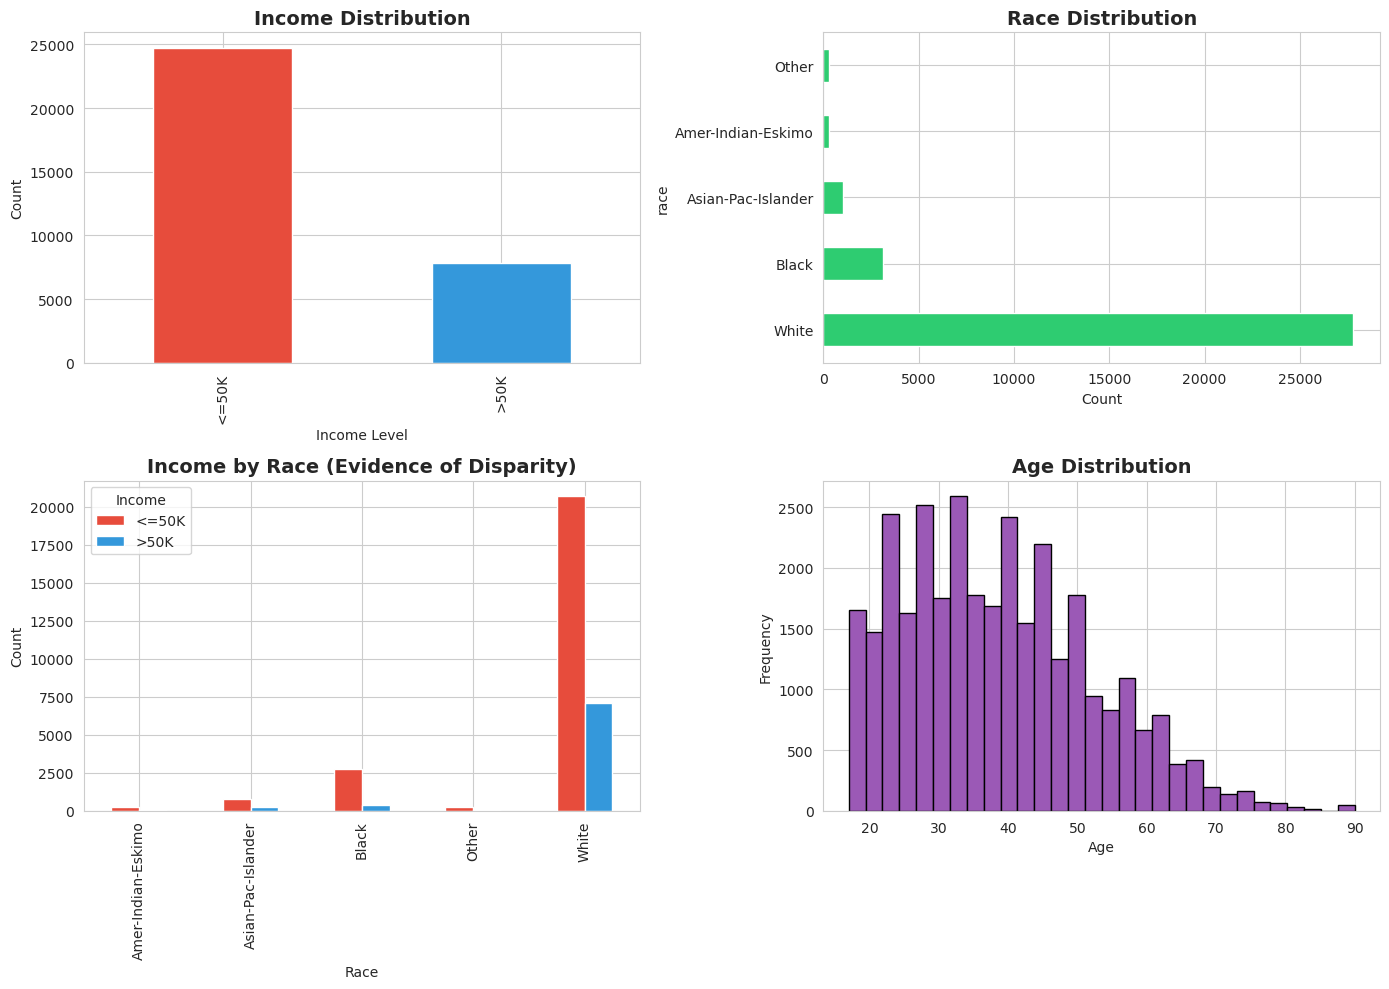

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Create subplot layout
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Income distribution
df['income'].value_counts().plot(kind='bar', ax=axes[0,0], color=['#e74c3c', '#3498db'])
axes[0,0].set_title('Income Distribution', fontsize=14, fontweight='bold')
axes[0,0].set_ylabel('Count')
axes[0,0].set_xlabel('Income Level')

# 2. Race distribution
df['race'].value_counts().plot(kind='barh', ax=axes[0,1], color='#2ecc71')
axes[0,1].set_title('Race Distribution', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Count')

# 3. Income by Race (showing bias)
race_income_counts = pd.crosstab(df['race'], df['income'])
race_income_counts.plot(kind='bar', ax=axes[1,0], color=['#e74c3c', '#3498db'])
axes[1,0].set_title('Income by Race (Evidence of Disparity)', fontsize=14, fontweight='bold')
axes[1,0].set_ylabel('Count')
axes[1,0].set_xlabel('Race')
axes[1,0].legend(title='Income')

# 4. Age distribution
df['age'].hist(bins=30, ax=axes[1,1], color='#9b59b6', edgecolor='black')
axes[1,1].set_title('Age Distribution', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Age')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('eda_visualizations.png', dpi=300, bbox_inches='tight')
print("✓ Visualizations saved: eda_visualizations.png")
plt.show()

In [10]:
# Upload visualization to S3
viz_file = 'eda_visualizations.png'
s3_client.upload_file(viz_file, bucket_name, f'data/visualizations/{viz_file}')
print(f"✓ Visualization uploaded to S3: s3://{bucket_name}/data/visualizations/{viz_file}")

# Final EDA Summary
print("\n" + "="*60)
print("EDA SUMMARY - Week 3 Deliverable COMPLETE")
print("="*60)
print(f"✓ S3 Bucket Created: s3://hiring-bias-505929363203")
print(f"✓ Dataset Loaded: 32,561 records × 15 features")
print(f"✓ Data Uploaded to S3: data/raw/adult_income.csv")
print(f"✓ Visualizations Created & Uploaded")
print(f"\nKEY FINDINGS FOR BIAS DETECTION:")
print(f"  • White individuals: 25.59% earn >50K")
print(f"  • Black individuals: 12.39% earn >50K (52% disparity)")
print(f"  • Amer-Indian-Eskimo: 11.58% earn >50K (55% disparity)")
print(f"\n✓ Ready for next steps: Feature Engineering & Model Training")
print("="*60)

✓ Visualization uploaded to S3: s3://hiring-bias-505929363203/data/visualizations/eda_visualizations.png

EDA SUMMARY - Week 3 Deliverable COMPLETE
✓ S3 Bucket Created: s3://hiring-bias-505929363203
✓ Dataset Loaded: 32,561 records × 15 features
✓ Data Uploaded to S3: data/raw/adult_income.csv
✓ Visualizations Created & Uploaded

KEY FINDINGS FOR BIAS DETECTION:
  • White individuals: 25.59% earn >50K
  • Black individuals: 12.39% earn >50K (52% disparity)
  • Amer-Indian-Eskimo: 11.58% earn >50K (55% disparity)

✓ Ready for next steps: Feature Engineering & Model Training
